# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = '../'

logger = logging.getLogger('recsys')
logger.setLevel(0)

%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet(ROOT + "data/tracks.parquet")
catalog_names = pd.read_parquet(ROOT + "data/catalog_names.parquet")
interactions = pd.read_parquet(ROOT + "data/interactions.parquet")

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

#### Набор **tracks**

In [3]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [4]:
tracks.sample(8).T

,535213,503285,285529,464282,716182,189501,980222,448732
track_id,37013747,34828879,18070711,32344246,53039834,5936688,93093771,31315101
albums,[4677181],"[4307814, 4307816]","[2002051, 10804976, 12343219, 14725526]",[3940426],[7549018],"[650796, 8777471]",[18718736],[3794519]
artists,[2689006],[783825],[515726],"[3685520, 3940681]","[6863750, 11146176]",[1116767],"[9191159, 12994302]",[452202]
genres,"[2, 102]","[68, 101]",[325],"[2, 102]",[11],"[14, 102]",[11],[11]


In [5]:
tracks[tracks.apply(lambda x: len(x['albums']) == 0 or len(x['artists']) == 0 or len(x['genres']) == 0, axis=1)]

,track_id,albums,artists,genres
490,2520,"[249, 163801, 163802, 324616, 17542430, 189498...",[2259],[]
3069,16776,"[1479, 5319, 6093, 8467, 10641, 90867, 163801,...",[978],[]
3077,16801,"[1479, 163801, 9287549, 9377183, 9424994, 1201...",[10520],[]
4192,23752,"[2001, 3722, 4973, 6104, 6558, 23866, 37052, 7...",[13373],[]
6645,38012,"[3147, 60099, 530836, 1115289, 2490724, 818446...",[16758],[]
...,...,...,...,...
999868,101201589,[12649219],[],"[62, 77]"
999876,101219571,[9444321],[],"[62, 83, 77]"
999901,101243616,[11700332],[],"[62, 93]"
999920,101292599,[9331881],[],"[62, 90, 77, 84]"


#### **Набор catalog_names**

In [6]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [7]:
catalog_names.isnull().sum()

id      0
type    0
name    0
dtype: int64

In [8]:
catalog_names.sample(8).T

,1672129,976389,1640038,19389,1744609,1420990,1274133,875084
id,69766795,4266242,65618215,58398,81017706,42360679,32192218,598424
type,track,track,track,album,track,track,track,track
name,Я тебя выдумал,Staggered Injection,Better Than Us,Respect M.E.,Oasis,Your Battles Are Over,And Then...,Колокола


In [9]:
catalog_names['type'].value_counts()

type
track     1000000
album      658724
artist     153581
genre         166
Name: count, dtype: int64

#### Набор **interactions**

In [10]:
interactions.sample(8).T

,196,11,51,28,1116,6513,30,90
user_id,457248,53788,550192,998897,165793,1055078,1170636,56543
track_id,301147,60220479,4254207,8768779,403820,49198563,21686088,15477535
track_seq,197,12,52,29,1117,6514,31,91
started_at,2022-05-10 00:00:00,2022-12-27 00:00:00,2022-12-03 00:00:00,2022-10-01 00:00:00,2022-02-14 00:00:00,2022-11-09 00:00:00,2022-09-05 00:00:00,2022-07-05 00:00:00


In [11]:
interactions.describe()

,user_id,track_id,track_seq,started_at
count,2.226299e+08,2.226299e+08,2.226299e+08,222629898
mean,6.875767e+05,3.653622e+07,4.621403e+02,2022-08-29 16:39:44.541336320
min,0.000000e+00,2.600000e+01,1.000000e+00,2022-01-01 00:00:00
25%,3.433710e+05,1.480849e+07,5.600000e+01,2022-07-02 00:00:00
50%,6.879730e+05,3.552474e+07,1.810000e+02,2022-09-15 00:00:00
75%,1.031127e+06,5.651137e+07,5.060000e+02,2022-11-09 00:00:00
max,1.374582e+06,1.015218e+08,1.663700e+04,2022-12-31 00:00:00
std,3.969033e+05,2.661782e+07,8.257312e+02,NaN


In [12]:
interactions.isnull().sum()

user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64

In [13]:
interactions['user_id'].nunique()

1373221

# Выводы

Приведём выводы по первому знакомству с данными:
- есть треки с незаполненными данными в колонках: albums, artists, genres

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

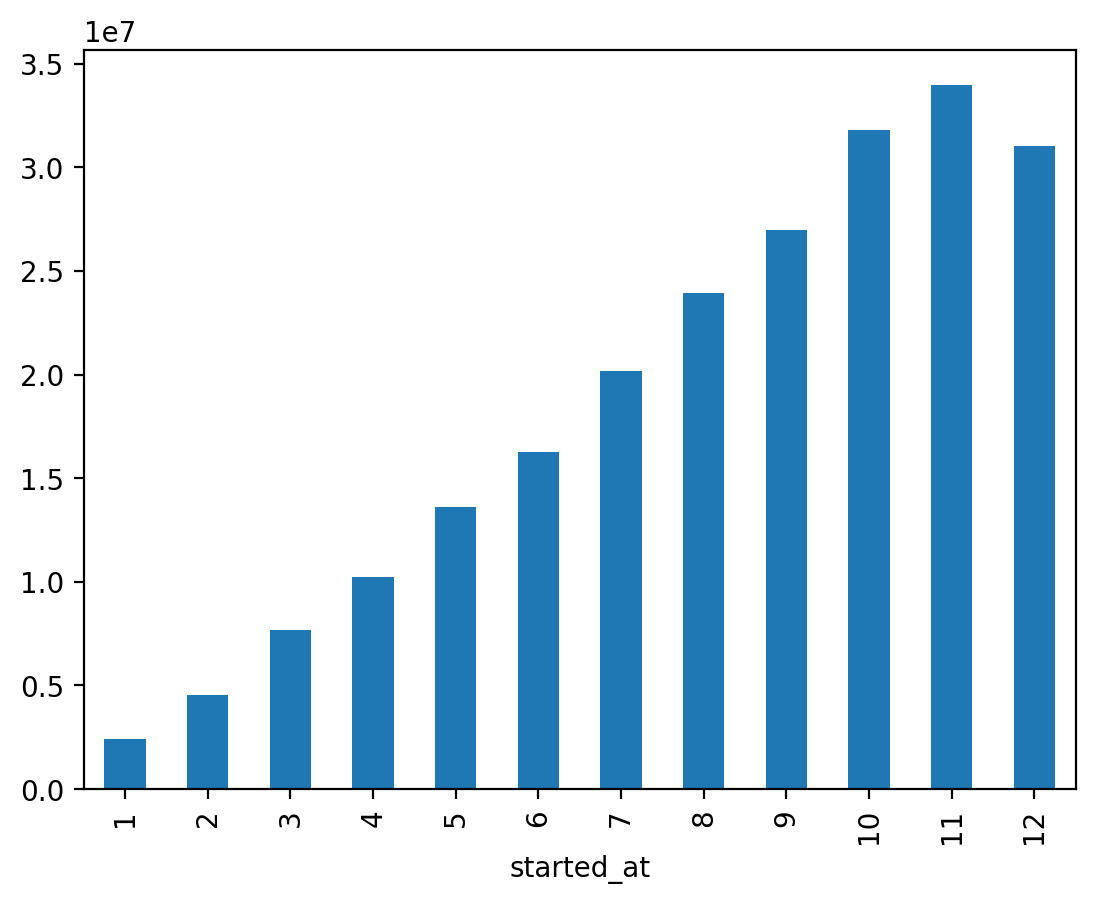

In [14]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind="bar")

Распределение рейтинга

<Axes: >

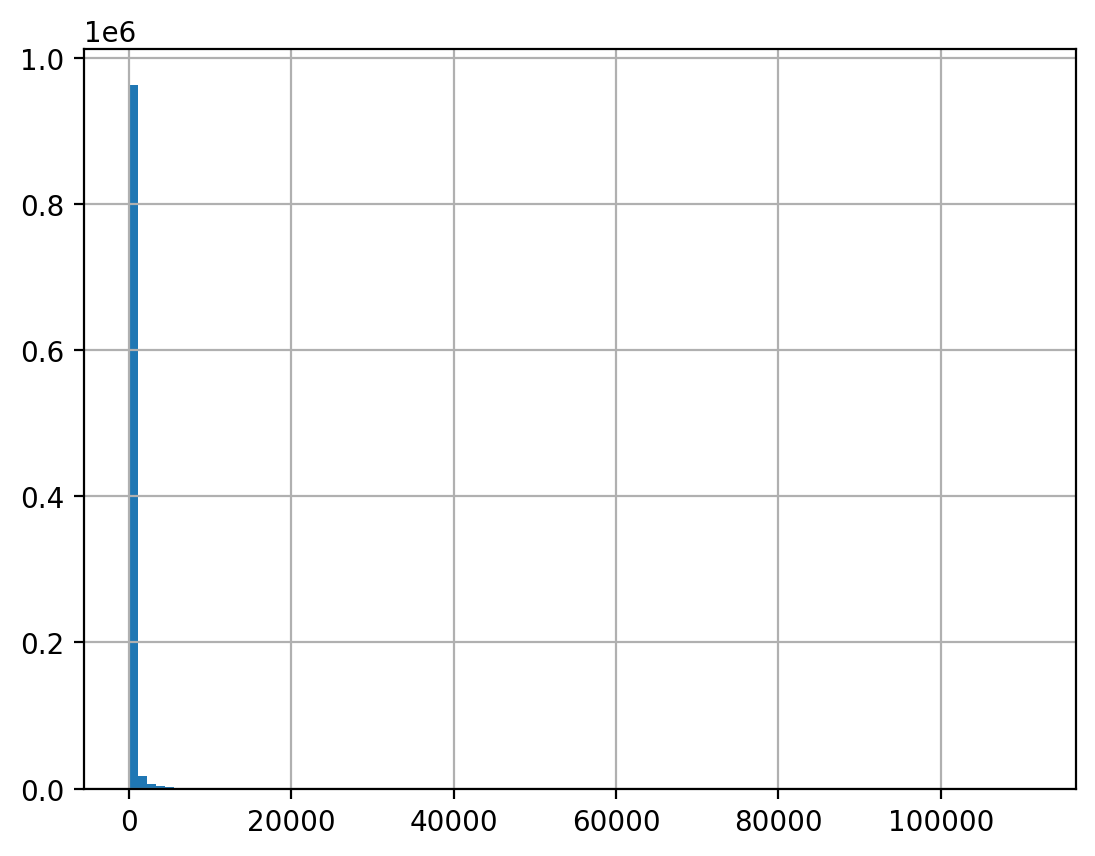

In [15]:
track_count = interactions.groupby(['track_id']).agg(count=('user_id', 'count')).reset_index()
track_count['count'].hist(bins=100)

(39849, 2)


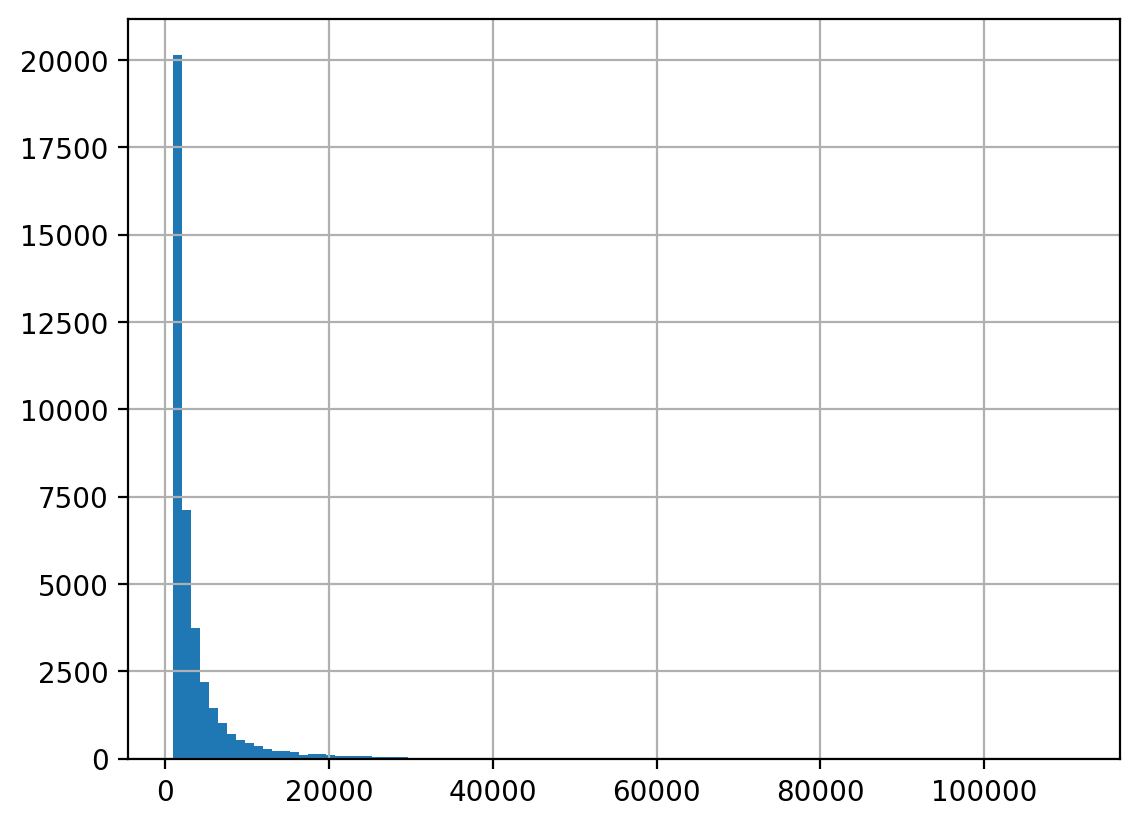

In [16]:
track_count.query('count > 1000')['count'].hist(bins=100)
print(track_count.query('count > 1000').shape)

In [ ]:
user_count = interactions.groupby(['user_id']).agg(count=('track_id', 'count')).reset_index()
user_count['count'].hist(bins=100)

<Axes: >

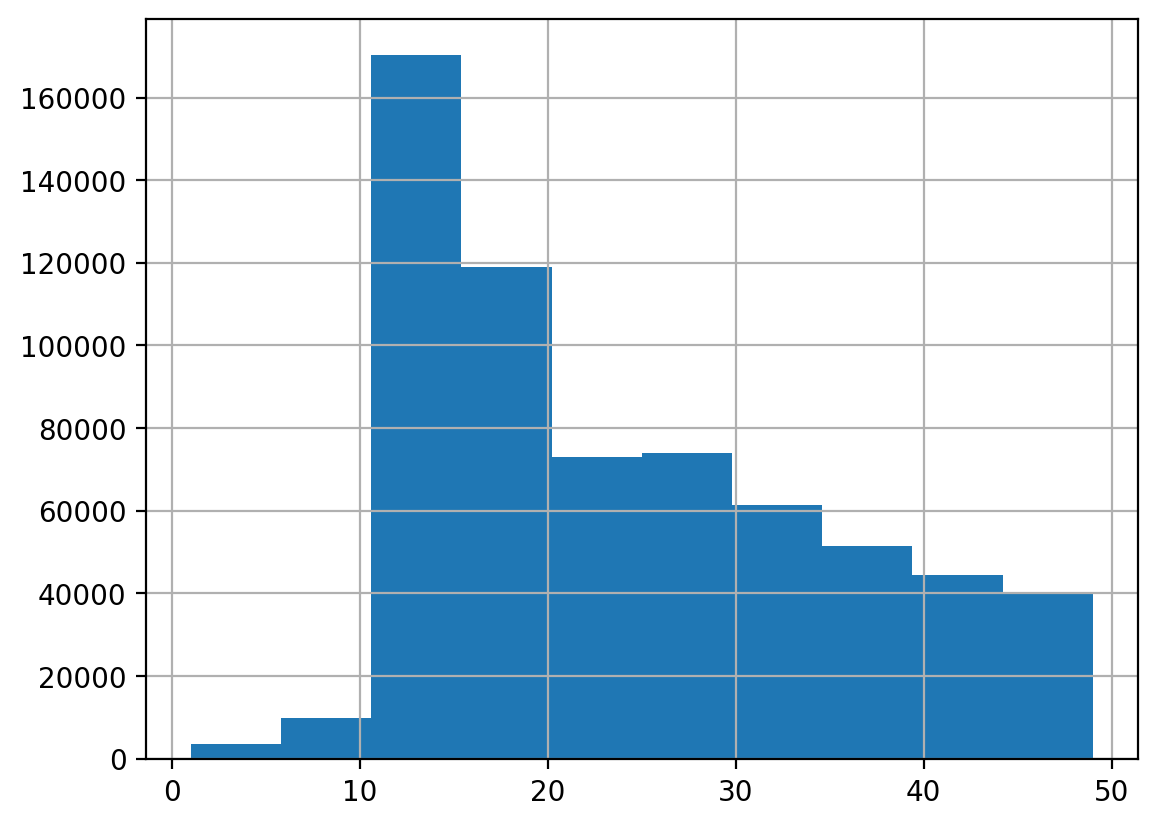

In [18]:
user_count.query('count < 50')['count'].hist()

Наиболее популярные треки

In [19]:
# most_popular = pd.DataFrame(interactions[['track_id']].value_counts().head(10)).reset_index()

# most_popular = most_popular.merge(catalog_names, left_on=['track_id'], right_on=['id'], how='left')
# most_popular = most_popular \
#     .merge(tracks_straight.query('type == "artist"'), on=['track_id'], how='left') \


# most_popular = most_popular \
#     .merge(tracks_straight.query('type == "artist"'), on=['track_id'], how='left') \
    
    


# most_popular = most_popular.merge(catalog_names, left_on=['track_id'], right_on=['id'], how='left')
# most_popular = most_popular.merge(catalog_names, left_on=['value'], right_on=['id'], how='left')

# most_popular
# als_recommendations = (
#     als_recommendations
#     .merge(events_test[["user_id", "item_id", "rating"]]
#         .rename(columns={"rating": "rating_test"}), 
#         on=["user_id", "item_id"], how="left")
# ) 


Наиболее популярные жанры

Треки, которые никто не прослушал

# Преобразование данных

In [20]:
interactions

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [21]:
interactions.shape


(222629898, 4)

In [22]:
users_to_drop = interactions.groupby('user_id').agg(count=('track_seq', 'max')).reset_index().query('count < 11')

In [22]:
interactions = interactions.query('track_seq < 11')

tracks_count = interactions.groupby(['track_id']).agg(count=('user_id', 'count')).reset_index()
interactions = interactions[interactions['track_id'].isin(tracks_count.query('count > 1000')['track_id'])]


In [25]:
interactions

,user_id,track_id,track_seq,started_at
6,0,597196,7,2022-07-25
7,0,597199,8,2022-07-25
0,1,24417,1,2022-06-11
1,2,672689,2,2022-04-19
0,3,6006252,1,2022-02-05
...,...,...,...,...
7,1374581,545860,8,2022-04-16
8,1374581,582507,9,2022-04-16
0,1374582,106716,1,2022-11-07
2,1374582,666207,3,2022-11-07


In [46]:
interactions.sample(3).T

,200244713,125790930,198808329
user_id,1236829,777084,1228054
track_id,70145628,30213641,36428269
track_seq,274,187,67
started_at,2022-12-13 00:00:00,2022-06-25 00:00:00,2022-11-12 00:00:00
tracks_count,874,3675,811


Удалим пользователей, у которых менее 10 треков

In [34]:
tracks_count = interactions.groupby(['track_id']).agg(count=('user_id', 'count')).reset_index()
tracks_count = tracks_count.query('count > 100')


In [37]:
interactions = interactions.merge(tracks_count, on='track_id', how='left')
interactions.shape

(204670742, 6)

In [39]:
interactions

,user_id,track_id,track_seq,started_at,count_x,count_y
0,0,99262,1,2022-07-17,2524,2524
1,561,99262,9,2022-08-06,2524,2524
2,569,99262,46,2022-04-06,2524,2524
3,895,99262,17,2022-06-09,2524,2524
4,1559,99262,9,2022-08-27,2524,2524
...,...,...,...,...,...,...
204670737,1323259,29098296,2720,2022-06-24,118,118
204670738,1328421,29098296,1720,2022-06-13,118,118
204670739,1328916,29098296,108,2022-05-22,118,118
204670740,1344120,29098296,95,2022-12-21,118,118


In [20]:
tracks_genres = tracks.explode('genres', ignore_index=True)[['track_id', 'genres']]
tracks_genres.rename(columns={'genres': 'genre'}, inplace=True)

popularity = interactions.groupby(['track_id']).agg(count=('user_id', 'count')).reset_index()
popularity = popularity.merge(tracks_genres, on='track_id', how='left')

genre_agg = popularity.groupby(['genre']).agg(genre_count_max=('count', 'max')).reset_index()
popularity = popularity.merge(genre_agg, on='genre', how='left')

popularity['rating'] = 0

for _, row in genre_agg.iterrows():
    genre = row['genre']
    genre_idx = popularity['genre'] == genre
    genre_popularity = popularity[genre_idx]
    popularity.loc[genre_idx, 'rating'] = pd.qcut(popularity[genre_idx]['count'], q=10, labels=False, duplicates='drop').astype('int')

popularity['rating'] = (popularity['rating'] + popularity['count'] / popularity['genre_count_max'])
popularity = popularity.groupby(['track_id']).agg(rating=('rating', 'mean'), count=('count', 'max')).reset_index()

In [25]:
popularity.sample(8).T

,508138,915244,702553,774874,227382,533967,769954,883141
track_id,3.523013e+07,7.811221e+07,5.191321e+07,5.976271e+07,1.080491e+07,3.694611e+07,5.925411e+07,7.274539e+07
rating,4.333632e+00,3.500171e+00,9.021921e+00,3.501651e+00,6.000413e+00,4.500449e+00,4.000144e+00,1.991013e-04
count,1.600000e+01,1.700000e+01,1.797000e+03,1.400000e+01,2.600000e+01,1.600000e+01,1.600000e+01,5.000000e+00


In [26]:
interactions = interactions.merge(popularity, on='track_id', how='left')

In [27]:
interactions.sample(8).T

,181128026,203286124,58600856,61799425,154262970,66745158,56626590,142352690
user_id,1118979,1255706,361645,381872,952720,412126,349227,879425
track_id,43566465,67854450,348483,23746590,18818856,252842,560420,2083086
track_seq,234,483,264,2,436,28,27,356
started_at,2022-09-23 00:00:00,2022-10-06 00:00:00,2022-05-03 00:00:00,2022-08-26 00:00:00,2022-07-26 00:00:00,2022-03-06 00:00:00,2022-05-25 00:00:00,2022-08-30 00:00:00
rating,9.041732,9.221299,8.002181,9.015902,8.003212,9.010075,9.115566,9.007226
count,3389,19180,189,1416,277,1119,9385,486


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [29]:
items = tracks
events = interactions

items = items.rename(columns={'track_id': 'item_id'})
events = events.rename(columns={'track_id': 'item_id'})

# items.to_parquet(ROOT + "data/items.parquet")
# events.to_parquet(ROOT + "data/events.parquet")

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [1]:
del tracks
del interactions

NameError: name 'tracks' is not defined

In [2]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = '../'

logger = logging.getLogger('recsys')
logger.setLevel(0)

%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [3]:
items = pd.read_parquet(ROOT + "data/items.parquet")
events = pd.read_parquet(ROOT + "data/events.parquet")

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [4]:
train_split_date = pd.to_datetime('2022-11-01').to_datetime64()
train_split_date_idx = events['started_at'] < train_split_date

events_train = events[train_split_date_idx]
events_test = events[~train_split_date_idx]

# количество пользователей в train и test
users_train = events_train['user_id'].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train) & set(users_test)

print(len(users_train), len(users_test), len(common_users)) 

644598 1135770 420453


In [5]:
events_train.shape, events_test.shape

((4206550, 7), (8817228, 7))

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

In [8]:
from surprise import Dataset, Reader
from surprise import SVD

# используем Reader из библиотеки surprise для преобразования событий (events)
# в формат, необходимый surprise
reader = Reader(rating_scale=(1, 5))
surprise_train_set = Dataset.load_from_df(events_train[['user_id', 'item_id', 'rating']], reader)
surprise_train_set = surprise_train_set.build_full_trainset()

# инициализируем модель
svd_model = SVD(n_factors=100, random_state=0)

# обучаем модель
svd_model.fit(surprise_train_set) 

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.